In [1]:
import pandas as pd
from cartopy import crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
from xhistogram.xarray import histogram
import numpy as np
import gfdl_utils as gu
import glob
import re
from scipy.interpolate import griddata
import geopy
import cmocean
import xesmf as xe
import sectionate
from geopy import distance
import sys
import cartopy.feature as cfeature;

sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *

In [2]:
plotsdir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/figures/" + x
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/" + x

In [3]:
# GLODAP:model variable naming conventions
model2glodap_names = {'cfc12':'cfc12','cfc11':'cfc11','sf6':'sf6','thetao':'theta','so':'salinity'}
variable_kwargs = {
    'cfc12':{'conversion':1e12/1035,'cmap':'Greens','units':'pmolkg-1'},
    'cfc11':{'conversion':1e12/1035,'cmap':'PuRd','units':'pmolkg-1'},
    'sf6':{'conversion':1e12/1035 * 1e3,'cmap':'PuRd','units':'fmolkg-1'},
    'theta':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'degK','bins':np.arange(-2,35,0.2),'anombins':np.arange(-4,4.05,0.05)},
    'salinity':{'conversion':1,'cmap':cmocean.cm.haline,'units':'psu','bins':np.arange(32,37,0.05),'anombins':np.arange(-1,1.02,0.02)}
}

In [29]:
ds_GLODAPP

<xarray.Dataset> Size: 1000MB
Dimensions:     (time: 31, lon: 240, lat: 120, sigma2: 20)
Coordinates:
  * lon         (lon) float64 2kB -180.0 -178.5 -177.0 ... 175.5 177.0 178.5
  * lat         (lat) float64 960B -90.0 -88.5 -87.0 -85.5 ... 85.5 87.0 88.5
  * sigma2      (sigma2) float64 160B 36.94 36.97 37.0 ... 37.29 37.34 37.41
  * time        (time) int64 248B 1990 1991 1992 1993 ... 2017 2018 2019 2020
Data variables:
    G2cfc12     (time, lon, lat, sigma2) float64 143MB ...
    G2cfc11     (time, lon, lat, sigma2) float64 143MB ...
    G2sf6       (time, lon, lat, sigma2) float64 143MB ...
    sa          (time, lon, lat, sigma2) float64 143MB ...
    ct          (time, lon, lat, sigma2) float64 143MB ...
    G2depth     (time, lon, lat, sigma2) float64 143MB ...
    G2pressure  (time, lon, lat, sigma2) float64 143MB nan nan nan ... nan nan

In [30]:
ds_GLODAPP = xr.open_dataset("GLODAP_gridded_sigma.nc")
ds_GLODAPP_bottom = ds_GLODAPP.sel(sigma2 = 37.0665, method = "nearest")
ds_GLODAPP_bottom = ds_GLODAPP_bottom.where(ds_GLODAPP_bottom.G2pressure > 3000)
ds_GLODAPP_bottom = ds_GLODAPP_bottom
# ds_GLODAPP = get_sigma2(ds_GLODAPP)

getfattr: /scratch/anthony.meza/CM4XAbyssalSWMT/notebooks/AABW_Thesis_Chapter2_DSW_Notebooks/GLODAP_gridded_sigma.nc: Operation not supported


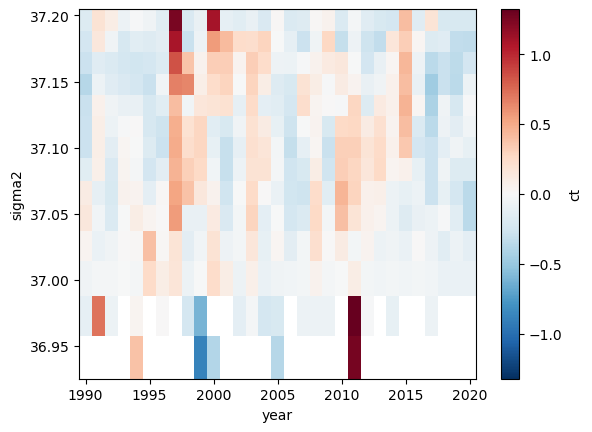

In [31]:
glodap_hov = (ds_GLODAPP.where(ds_GLODAPP.G2pressure > 3000).rename({"time":"year"}))
glodap_hov = glodap_hov.ct.mean(["lon", "lat"])
    
glodap_hov = glodap_hov.T.sel(sigma2 = slice(36.8, 37.2))
glodap_hov = glodap_hov - glodap_hov.mean("year")
glodap_hov.plot()

In [32]:
ds_bottom = xr.open_dataset(datadir("model/global_bottom_tracers_sigma2_yearly.nc"))
ds_bottom = ds_bottom.sel(sigma2_l = 36.9415, method = "nearest")
ds_bottom['p'] = xr.apply_ufunc(
    gsw.p_from_z, ds_bottom.z, ds_bottom.lat, 0, 0, dask="parallelized"
)

regridder = xe.Regridder(ds_bottom, ds_GLODAPP_bottom, method = "bilinear", periodic = True, parallel = False) #need to put Periodic = True for MOM6
ds_bottom_regrid = regridder(ds_bottom)
ds_bottom_regrid = ds_bottom_regrid.where(ds_bottom_regrid.p > 3000)

getfattr: /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/global_bottom_tracers_sigma2_yearly.nc: Operation not supported


In [33]:
ds_bottom_regrid_abyssal = ds_bottom_regrid
ds_GLODAPP_bottom_abyssal = ds_GLODAPP_bottom.rename({"time":"year"})

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.10/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


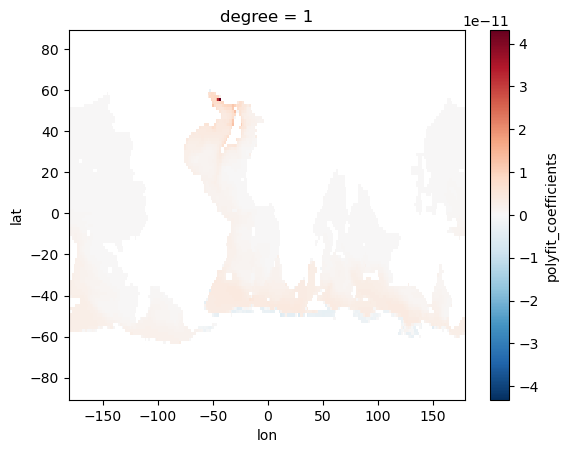

In [34]:
p = ds_bottom_regrid_abyssal.sel(exp = "forced").cfc11.polyfit(dim="year", deg=1, skipna=True)
trend = p.polyfit_coefficients.sel(degree=1)
trend.plot(x = "lon", y = "lat")

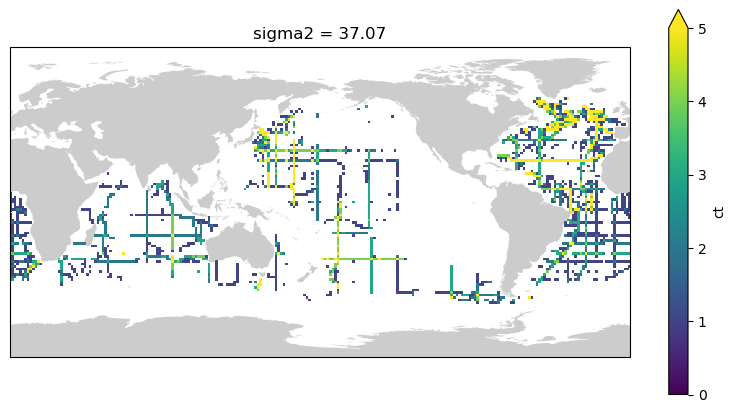

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), subplot_kw={'projection':ccrs.PlateCarree(central_longitude = 180)})
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor=None, facecolor='grey', alpha = 0.4))
num_obs = ((~np.isnan(ds_GLODAPP_bottom_abyssal.ct)).sum(["year"]))
num_obs.where(num_obs > 0).T.plot(ax = ax,transform=ccrs.PlateCarree(), vmin = 0, vmax = 5)

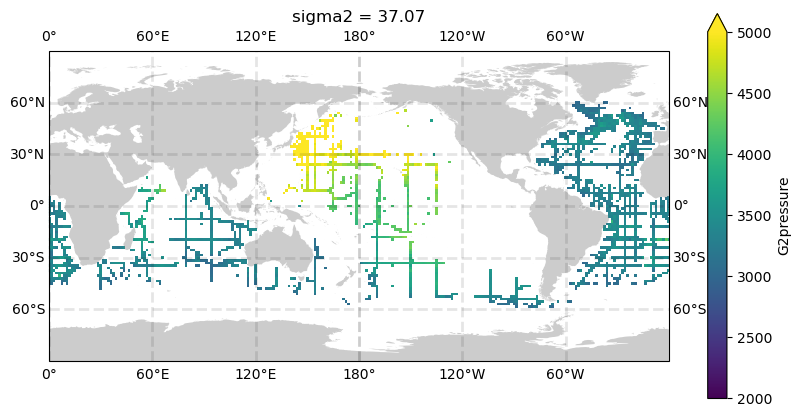

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), subplot_kw={'projection':ccrs.PlateCarree(central_longitude = 180)})
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor=None, facecolor='grey', alpha = 0.4))
ds_GLODAPP_bottom_abyssal.G2pressure.mean(["year"]).T.plot(ax = ax,transform=ccrs.PlateCarree(), vmin = 2000, vmax = 5000)
gl = ax.gridlines(crs=ccrs.PlateCarree(), linewidth=2, color='black', alpha=0.1, linestyle='--', draw_labels=True, zorder = 0)
# ax.coastlines()

In [101]:
LON, LAT = np.meshgrid(ds_GLODAPP_bottom_abyssal.lon, ds_GLODAPP_bottom_abyssal.lat)
mask1 = (-60.0 <= LAT) *  (LAT <= 0.0) * (-180 <= LON) * (LON <= -125)
mask2 = (0.0 <= LAT) *  (LAT < 30.0) * (150 <= LON) * (LON <= 180)
mask3 = (-30.0 <= LAT) *  (LAT <= 0.0) * (170 <= LON) * (LON <= 180)
mask4 = (0.0 <= LAT) *  (LAT < 30.0) * (-180 <= LON) * (LON <= -125)

mask = 1.0 * (mask3 + mask1)


region_mask = 1 * ds_bottom_regrid.ct.sel(exp = "forced").isel(year = 0)
region_mask.values = mask
region_mask = region_mask.where(region_mask > 0)

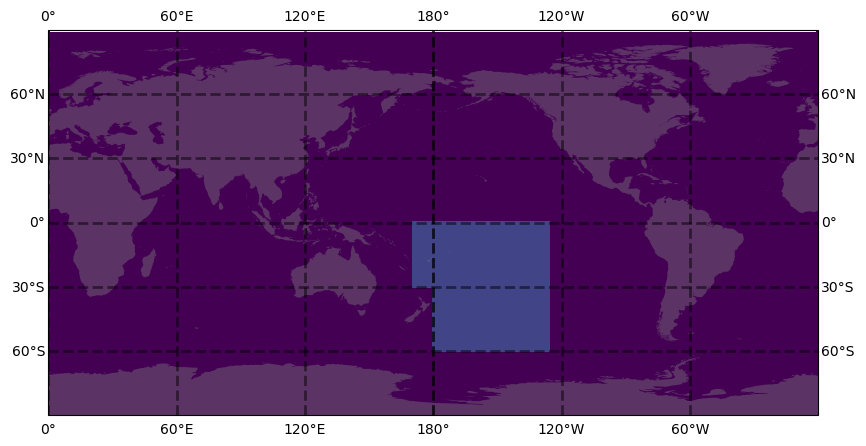

In [102]:
import cartopy.feature as cfeature;
fig, ax = plt.subplots(1, 1, figsize=(10, 5), subplot_kw={'projection':ccrs.PlateCarree(central_longitude = 180)})
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor=None, facecolor='grey', alpha = 0.4))

ax.pcolormesh(ds_GLODAPP_bottom_abyssal.lon, ds_GLODAPP_bottom_abyssal.lat, mask,transform=ccrs.PlateCarree(), vmin = 0, vmax = 5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), linewidth=2, color='black', alpha=0.5, linestyle='--', draw_labels=True)
# ax.coastlines()

In [103]:
pathway_mask = (~np.isnan(ds_GLODAPP_bottom_abyssal.ct)) * (~np.isnan(ds_bottom_regrid.sel(exp = "forced").cfc11)) 
pathway_mask = pathway_mask * (~np.isnan(ds_bottom_regrid.sel(exp = "control").cfc11)) 
pathway_mask = pathway_mask * region_mask
pathway_mask = pathway_mask.where(pathway_mask > 0)

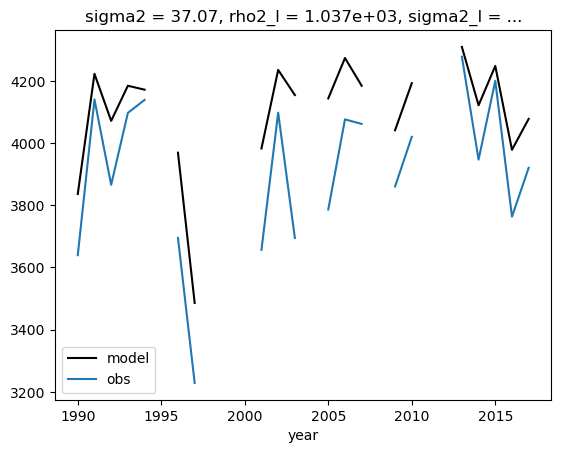

In [104]:
ds_bottom_regrid_abyssal_forced = ds_bottom_regrid.sel(exp = "forced")
fig, ax = plt.subplots()
(pathway_mask * ds_bottom_regrid_abyssal_forced.p).median(["lon", "lat"]).plot(ax = ax, c = "k", label = "model")
# ax2 = ax.twinx()
(pathway_mask * ds_GLODAPP_bottom_abyssal.G2pressure).median(["lon", "lat"]).plot(ax = ax, label = "obs")
ax.legend()
# ax.legend()

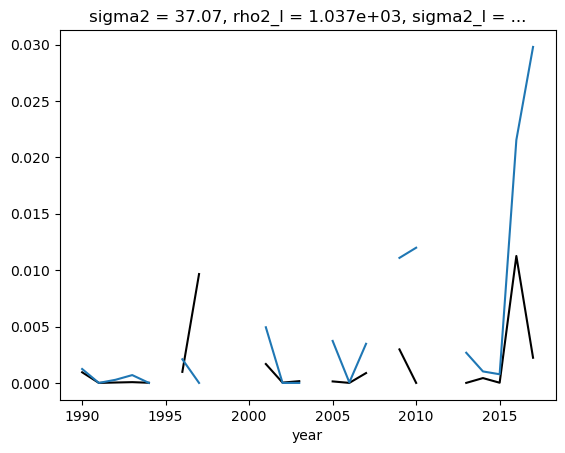

In [105]:
model_cfc = ds_bottom_regrid_abyssal_forced.cfc12.fillna(0.0)
model_cfc = model_cfc.where(pathway_mask > 0)

obs_cfc = ds_GLODAPP_bottom_abyssal.G2cfc12.fillna(0.0)
obs_cfc = obs_cfc.where(pathway_mask > 0)

fig, ax = plt.subplots()
(pathway_mask * model_cfc * variable_kwargs["cfc11"]["conversion"]).median(["lon", "lat"]).plot(ax = ax, c = "k", label = "forced")

(pathway_mask * obs_cfc).median(["lon", "lat"]).plot(ax = ax, label = "median")

# ax.legend()

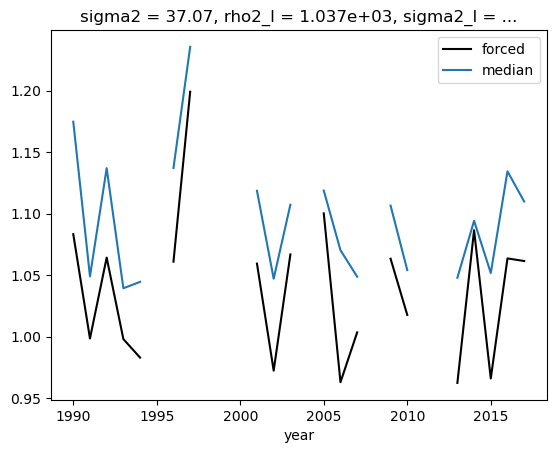

In [106]:
fig, ax = plt.subplots()
(pathway_mask * ds_bottom_regrid_abyssal_forced.ct).median(["lon", "lat"]).plot(ax = ax, c = "k", label = "forced")
(pathway_mask * ds_GLODAPP_bottom_abyssal.ct).median(["lon", "lat"]).plot(ax = ax, label = "median")
ax.legend()
# ax.legend()

In [112]:
nvalid = 7
def get_trend(ds, dim="year"):
    # Count non-NaN points along the fitting dimension
    valid_count = ds.notnull().sum(dim=dim)
    
    # Initialize with NaNs of the same shape but without the fitting dimension
    trend = xr.full_like(ds.isel({dim: 0}), np.nan)
    
    # Only perform polyfit where at least 2 valid points exist
    mask = valid_count >= nvalid
    if mask.any():
        p = ds.where(mask).polyfit(dim=dim, deg=1, skipna=True)
        trend = p.polyfit_coefficients.sel(degree=1)
    
    return trend

In [113]:
path_theta_obs = 10 * get_trend(ds_GLODAPP_bottom_abyssal.ct * pathway_mask)
path_theta_model = 10 * get_trend(ds_bottom_regrid_abyssal.ct * pathway_mask)

In [114]:
# path_theta_model_contaminated = 10 * get_trend(model_ct_contam * pathway_mask)

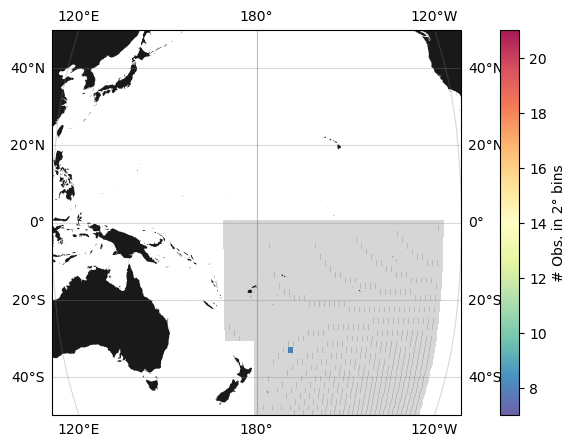

In [115]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Calculate pathway observations
pathway_obs = pathway_mask.sum("year")
pathway_obs = pathway_obs.where(pathway_obs > nvalid)

# Create figure with Plate Carrée projection centered at 180°
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.Robinson(central_longitude=180)})

# Set extent: [lon_min, lon_max, lat_min, lat_max]
ax.set_extent([120, 240, -50, 50], crs=ccrs.PlateCarree())


# Add land feature
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor=None, facecolor='k', alpha=0.9))

from matplotlib.colors import ListedColormap

# Create custom colormap: transparent for 0, light red for 1
colors = [(1, 1, 1, 0), (1, 0.5, 0.5, 0.5)]  # RGBA: transparent, light red with alpha
cmap = ListedColormap(colors)

ax.pcolormesh(ds_GLODAPP_bottom_abyssal.lon, ds_GLODAPP_bottom_abyssal.lat, region_mask.where(region_mask > 0),
              transform=ccrs.PlateCarree(), vmin = -5, vmax = 5, cmap = "Greys", alpha = 0.3)

cb = ax.pcolormesh(ds_GLODAPP_bottom_abyssal.lon, ds_GLODAPP_bottom_abyssal.lat, pathway_obs.T,
              transform=ccrs.PlateCarree(), vmin = nvalid, vmax = 3 * nvalid, alpha = 0.9, cmap = "Spectral_r")
fig.colorbar(cb, ax = ax, label = "# Obs. in 2° bins")
# Add gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='grey', alpha=0.3, linestyle='-', draw_labels=True)

plt.show()

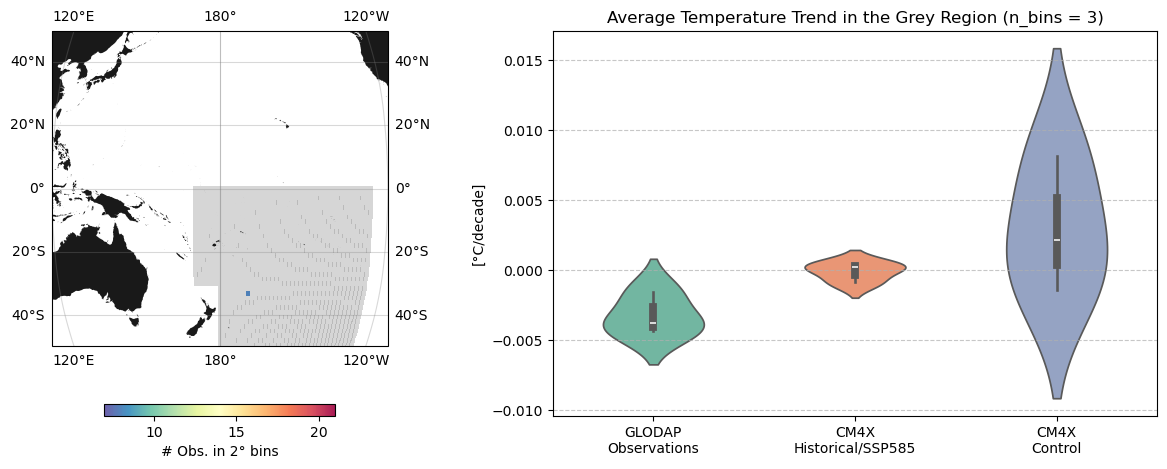

In [116]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd
import numpy as np

# Calculate pathway observations
pathway_obs = pathway_mask.sum("year")
pathway_obs = pathway_obs.where(pathway_obs > nvalid)

# Create figure with GridSpec for custom width ratios
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], hspace=0.3, wspace=0.05)

# ===== SUBPLOT 1: Map (1/3 width) =====
ax1 = fig.add_subplot(gs[0], projection=ccrs.Robinson(central_longitude=180))

# Set extent: [lon_min, lon_max, lat_min, lat_max]
ax1.set_extent([120, 240, -50, 50], crs=ccrs.PlateCarree())

# Add land feature
ax1.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor=None, facecolor='k', alpha=0.9))

ax1.pcolormesh(ds_GLODAPP_bottom_abyssal.lon, ds_GLODAPP_bottom_abyssal.lat, region_mask.where(region_mask > 0),
              transform=ccrs.PlateCarree(), vmin=-5, vmax=5, cmap="Greys", alpha=0.3)

cb = ax1.pcolormesh(ds_GLODAPP_bottom_abyssal.lon, ds_GLODAPP_bottom_abyssal.lat, pathway_obs.T,
              transform=ccrs.PlateCarree(), vmin=nvalid, vmax=3 * nvalid, alpha=0.9, cmap="Spectral_r")

fig.colorbar(cb, ax=ax1, label="# Obs. in 2° bins", orientation="horizontal", fraction=0.03)

# Add gridlines
gl = ax1.gridlines(crs=ccrs.PlateCarree(), color='grey', alpha=0.3, linestyle='-', draw_labels=True)

# ===== SUBPLOT 2: Boxplot (2/3 width) =====
ax2 = fig.add_subplot(gs[1])

# Clean data
obs = path_theta_obs.values[~np.isnan(path_theta_obs.values)]
mod = path_theta_model.sel(exp="forced").values
mod = mod[~np.isnan(mod)]
ctrl = path_theta_model.sel(exp="control").values
ctrl = ctrl[~np.isnan(ctrl)]
n_obs = len(obs)

# Put into DataFrame for seaborn
df = pd.DataFrame({
    'Temperature Trend (°C/decade)': np.concatenate([obs, mod, ctrl]),
    'Dataset': ['GLODAP\nObservations']*len(obs) + ['CM4X\nHistorical/SSP585']*len(mod) + ['CM4X\nControl']*len(ctrl)
})

sns.violinplot(
    x='Dataset',  # Swapped: was 'y'
    y='Temperature Trend (°C/decade)',  # Swapped: was 'x'
    data=df,
    orient='v',  # Changed from 'h' to 'v' for vertical
    palette="Set2",
    ax=ax2,
    width=0.5
)

ax2.set_xlabel("")  # Changed from set_ylabel
ax2.set_ylabel("[°C/decade]")  # Add y-axis label
ax2.set_title(f"Average Temperature Trend in the Grey Region (n_bins = {n_obs})")
ax2.grid(True, axis="y", linestyle="--", alpha=0.7)  # Changed from axis="x"
fig.savefig("plots/bottom_temp_GLODAP_comparison.png", dpi = 250, bbox_inches = "tight")